In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit
import os
import sys

sys.path.append(os.path.abspath(".."))

from libs import fit_model as fm 
from libs import cal_vel as cv
from libs import displacement as dpm

plt.style.use('../libs/my_style.mplstyle')

markers = ["o", "s", "v", "^", '*', 'd']
lines = ["-", "--", "-.", ":", (0, (5, 3, 1, 3, 1, 3))]

In [2]:
scale = 0.11
interval = 10

path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240827/MC00/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240926/MC00MT1uM/beads_tracks.csv"

MC10 = [path1, path2]

path1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM/beads_tracks.csv"
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240910/MC03MT083uM001/beads_tracks.csv"
path3 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20240926/MC03MT1uM/beads_tracks.csv"
path4 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241127/MC03MT1uM/beads_tracks.csv"

MC13 = [path1, path2, path3, path4]

path40_1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC00MT4uM/beads_tracks.csv"

path43_1 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC03MT4uM/beads_tracks.csv"
path43_2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251210/MC03MT4uM/beads_tracks.csv"

def get_msd(path, scale=0.11, interval=10, threshold = 0):
    track = cv.cal(pd.read_csv(path), scale=scale ,frame_interval=interval)
    track = track[track['v'] >= threshold]
    imsd = dpm.imsd(track, scale, interval, display=bool)
    emsd, _ = dpm.emsd(imsd, display=bool)

    return imsd, emsd

def get_emsd_err(IMSD):
    emsd = IMSD.groupby("lag time").mean()
    emsd_err = IMSD.groupby("lag time").sem()['MSD'].to_numpy()

    return emsd, emsd_err

def get_msd_df(path_list, scale=0.11, interval=10, threshold = 0):
    MSDs = []

    i = 0
    for path in path_list:
        imsd, _ = get_msd(path, scale, interval, threshold)
        imsd['particle'] += i*10000
        MSDs.append(imsd)
        i += 1

    MSDs = pd.concat(MSDs)

    return MSDs

In [3]:
MSDs10 = get_msd_df(MC10, scale, interval)
MSDs13 = get_msd_df(MC13, scale, interval)

I40_1, MSD40_1 = get_msd(path40_1, scale, interval)
I43_1, MSD43_1 = get_msd(path43_1, scale, interval)

/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:169: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  msd_df=pd.concat([msd_df, data])
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. Th

<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\D'
<>:40: SyntaxWarning: invalid escape sequence '\p'
<>:41: SyntaxWarning: invalid escape sequence '\p'
<>:48: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11240/2153875209.py:40: SyntaxWarning: invalid escape sequence '\p'
  ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11240/2153875209.py:41: SyntaxWarning: invalid escape sequence '\p'
  ax.text(120, 0.4*1e1, '$\propto \Delta ^{1.0}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11240/2153875209.py:48: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',


[(8.0, 300.0),
 (0.1, 100.0),
 None,
 None,
 Text(0.5, 0, 'lag time $\\Delta$ [s]'),
 Text(0, 0.5, 'MSD $\\langle \\Delta r^2 \\rangle$ $[μm^2]$')]

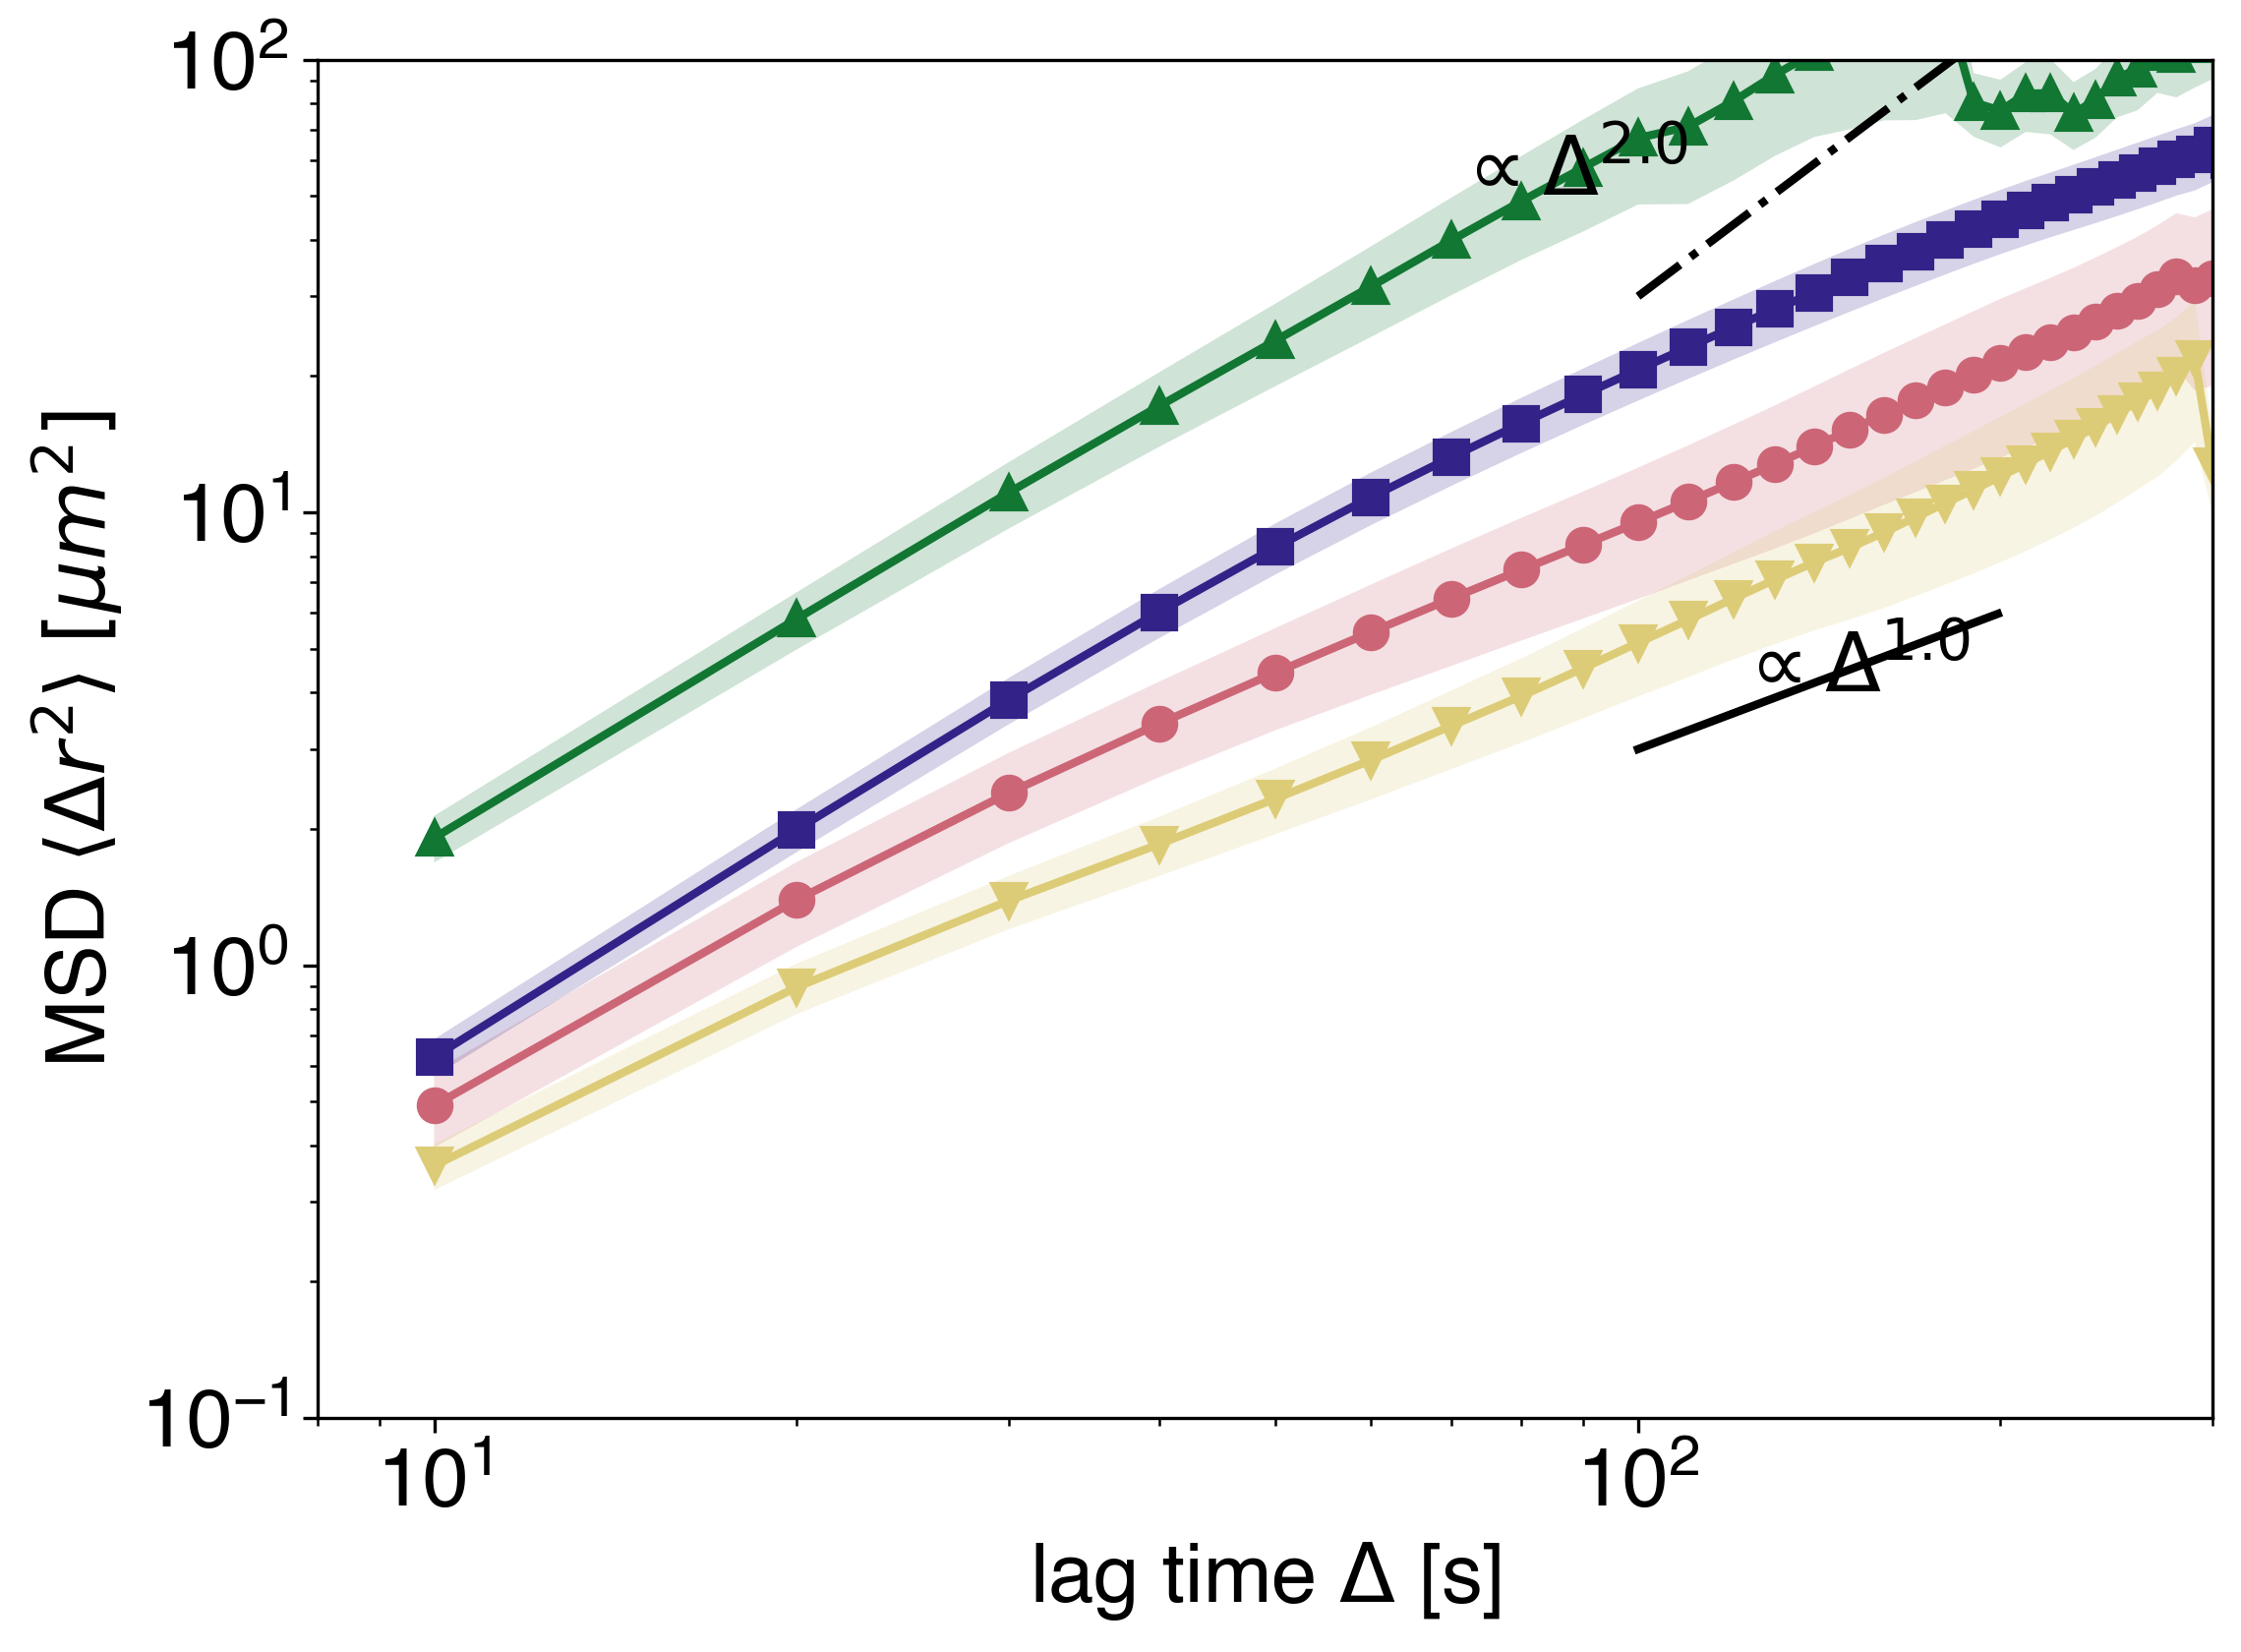

In [4]:
emsd10, emsd_err10 = get_emsd_err(MSDs10)
emsd13, emsd_err13 = get_emsd_err(MSDs13)
emsd40, emsd_err40 = get_emsd_err(I40_1)
emsd43, emsd_err43 = get_emsd_err(I43_1)

fig, ax = plt.subplots()

ax.plot(emsd10.index, emsd10['MSD'], marker=markers[0])
ax.fill_between(emsd10.index,
                emsd10['MSD'] - emsd_err10,
                emsd10['MSD'] + emsd_err10,
                alpha=0.2)

ax.plot(emsd13.index, emsd13['MSD'], marker=markers[1])
ax.fill_between(emsd13.index,
                emsd13['MSD'] - emsd_err13,
                emsd13['MSD'] + emsd_err13,
                alpha=0.2)

ax.plot(emsd40.index, emsd40['MSD'], marker=markers[2])
ax.fill_between(emsd40.index,
                emsd40['MSD'] - emsd_err40,
                emsd40['MSD'] + emsd_err40,
                alpha=0.2)

ax.plot(emsd43.index, emsd43['MSD'], marker=markers[3])
ax.fill_between(emsd43.index,
                emsd43['MSD'] - emsd_err43,
                emsd43['MSD'] + emsd_err43,
                alpha=0.2)

ty = np.arange(100, 200)

y2 = 3.0e-3 * ty ** 2.0
y3 = 0.03 * ty ** 1.0

ax.plot(ty, y2, c = 'black', linestyle = '-.')
ax.plot(ty, y3, c = 'black', linestyle = '-')

ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')
ax.text(120, 0.4*1e1, '$\propto \Delta ^{1.0}$')

ax.set(
    xlim=(0.8*1e1, 3e2),
    ylim=(1e-1, 1e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

In [5]:
def fit(emsd, minimum, maximum):
    # Fit log-log in a specified time window
    mask = (emsd.index > minimum) & (emsd.index < maximum)

    # take log10 of selected x and y values and convert to numpy arrays
    x = np.log10(emsd.index[mask].to_numpy())
    y = np.log10(emsd['MSD'][mask].to_numpy())

    # remove non-finite entries (e.g., log of non-positive values)
    finite = np.isfinite(x) & np.isfinite(y)
    x = x[finite]
    y = y[finite]

    # fit
    popt, pcov = curve_fit(fm.ln_pl, x, y, p0=[1.0, 1.0])

    return popt, pcov

minimum = 10
maximum = 200

popt40, pcov40 = fit(emsd40, minimum, maximum)
popt43, pcov43 = fit(emsd43, minimum, maximum)

print(f"40:{popt40[0]}")
print(f"43:{popt43[0]}")

40:1.1322242371446387
43:1.355980078864306


/Users/sasakinozomu/code/MTCargo_analysis/libs/fit_model.py:8: RuntimeWarning: invalid value encountered in log10
  return k * x + np.log10(a)


<>:69: SyntaxWarning: invalid escape sequence '\p'
<>:76: SyntaxWarning: invalid escape sequence '\D'
<>:69: SyntaxWarning: invalid escape sequence '\p'
<>:76: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11240/1682458727.py:69: SyntaxWarning: invalid escape sequence '\p'
  ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11240/1682458727.py:76: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').ap

v=[0.40210357]


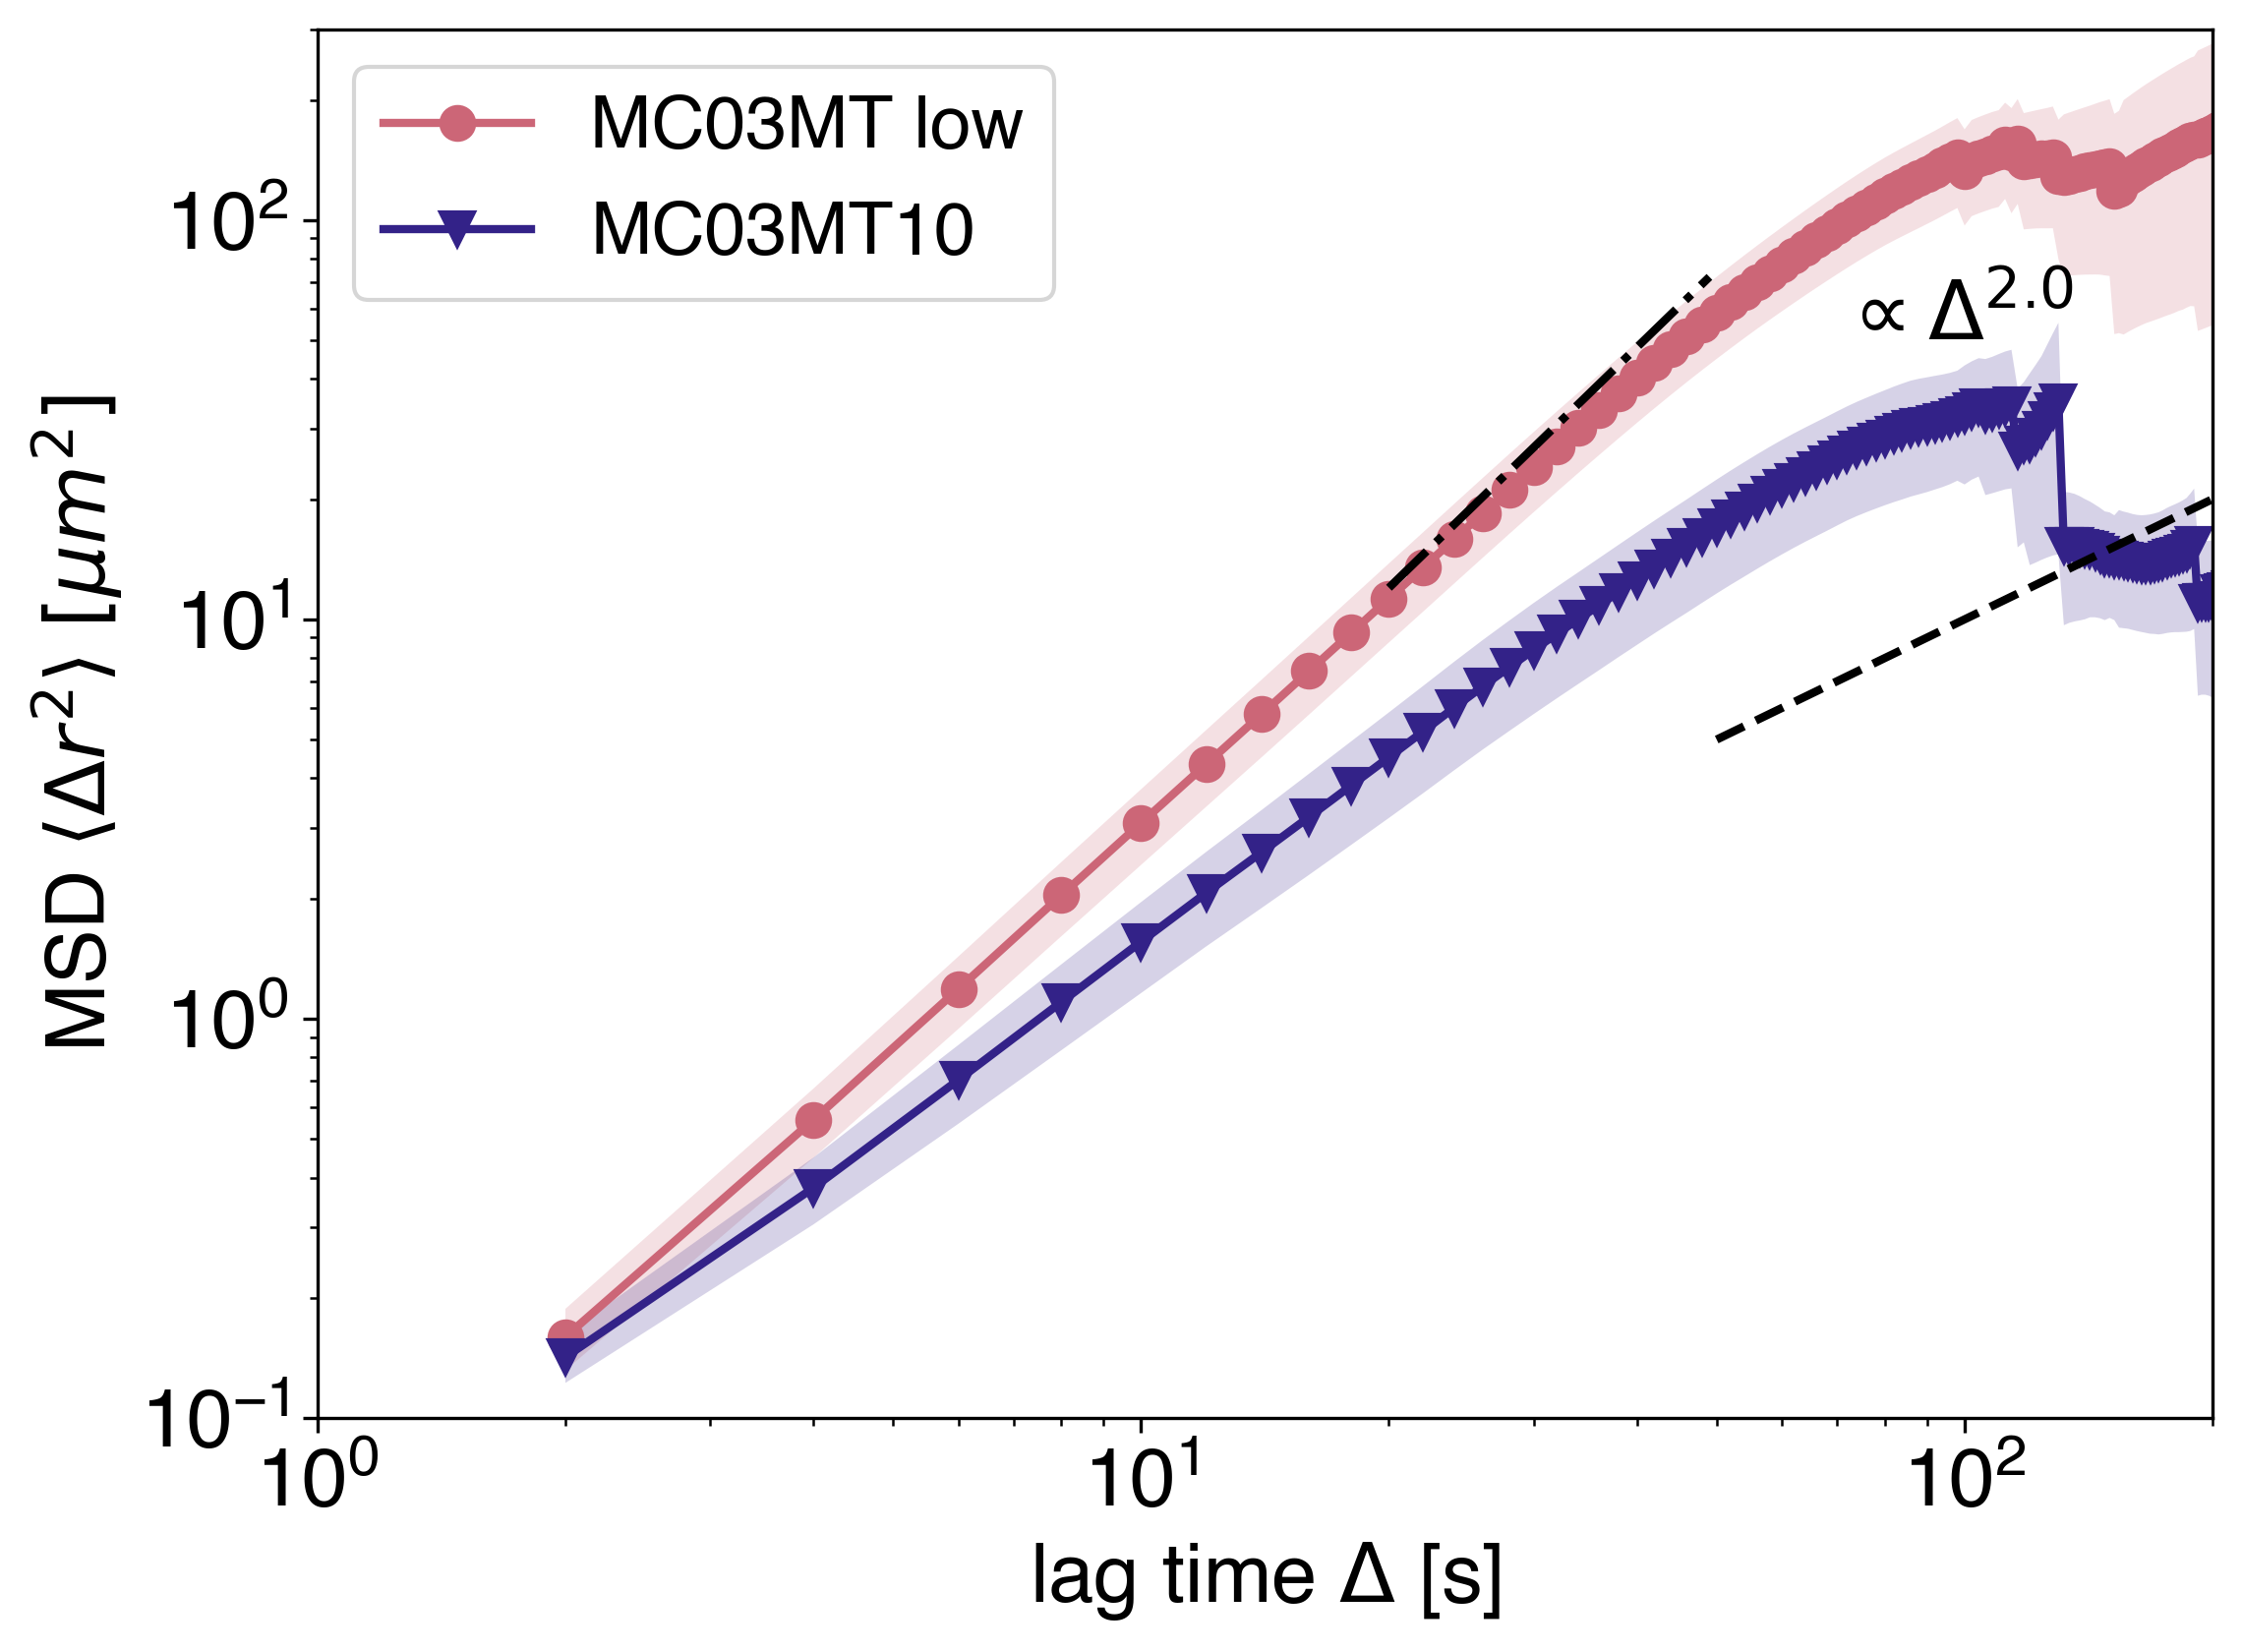

In [6]:
path1 = '/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251225/MC03MT/beads_tracks.csv'
path2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20251226/MC00MT/beads_tracks.csv"
path3 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20260107/MC03MT10/beads_tracks.csv"

interval_h = 2
scale = 0.11
minimum=10
maximum=55

def AB(t, v):
    return (v*t)**2

def lnAB(t, v):
    return 2*t + 2*np.log10(v)

I_h1, MSD_h1 = dpm.get_msd(path1, scale, interval_h, threshold=0.0)
I_h2, MSD_h2 = dpm.get_msd(path2, scale, interval_h, threshold=0.0)
I_h3, MSD_h3 = dpm.get_msd(path3, scale, interval_h, threshold=0.0)

emsd1, emsd_err1 = dpm.get_emsd_err(I_h1)
emsd2, emsd_err2 = dpm.get_emsd_err(I_h2)
emsd3, emsd_err3 = dpm.get_emsd_err(I_h3)
mask = (emsd1.index > minimum) & (emsd1.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd1.index[mask].to_numpy())
y = np.log10(emsd1['MSD'][mask].to_numpy())

 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]

# fit
popt, pcov = curve_fit(lnAB, x, y)

fig, ax = plt.subplots()

ax.plot(emsd1.index, emsd1['MSD'], marker=markers[0], label='MC03MT low')
ax.fill_between(emsd1.index,
                emsd1['MSD'] - emsd_err1,
                emsd1['MSD'] + emsd_err1,
                alpha=0.2)
"""
ax.plot(emsd2.index, emsd2['MSD'], marker=markers[1], label='MC00MT low')
ax.fill_between(emsd2.index,
                emsd2['MSD'] - emsd_err2,
                emsd2['MSD'] + emsd_err2,
                alpha=0.2)
"""
ax.plot(emsd3.index, emsd3['MSD'], marker=markers[2], label='MC03MT10')
ax.fill_between(emsd3.index,
                emsd3['MSD'] - emsd_err3,
                emsd3['MSD'] + emsd_err3,
                alpha=0.2)

#ax.plot(emsd1.index, AB(emsd1.index, popt))

t1 = np.arange(50, 200)
t2 = np.arange(20, 50)

y1 = 1.0e-1 * t1 ** 1.0
y2 = 3.0e-2 * t2 ** 2.0

ax.plot(t1, y1, c = 'black', linestyle = '--')
ax.plot(t2, y2, c = 'black', linestyle = '-.')


ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')

ax.set(
    xlim=(1e0, 2e2),
    ylim=(1e-1, 3e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

ax.legend()

print(f"v={np.sqrt(popt)}")

[1.37659324 0.07818144]


<>:59: SyntaxWarning: invalid escape sequence '\D'
<>:59: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11240/2245469182.py:59: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:169: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dt

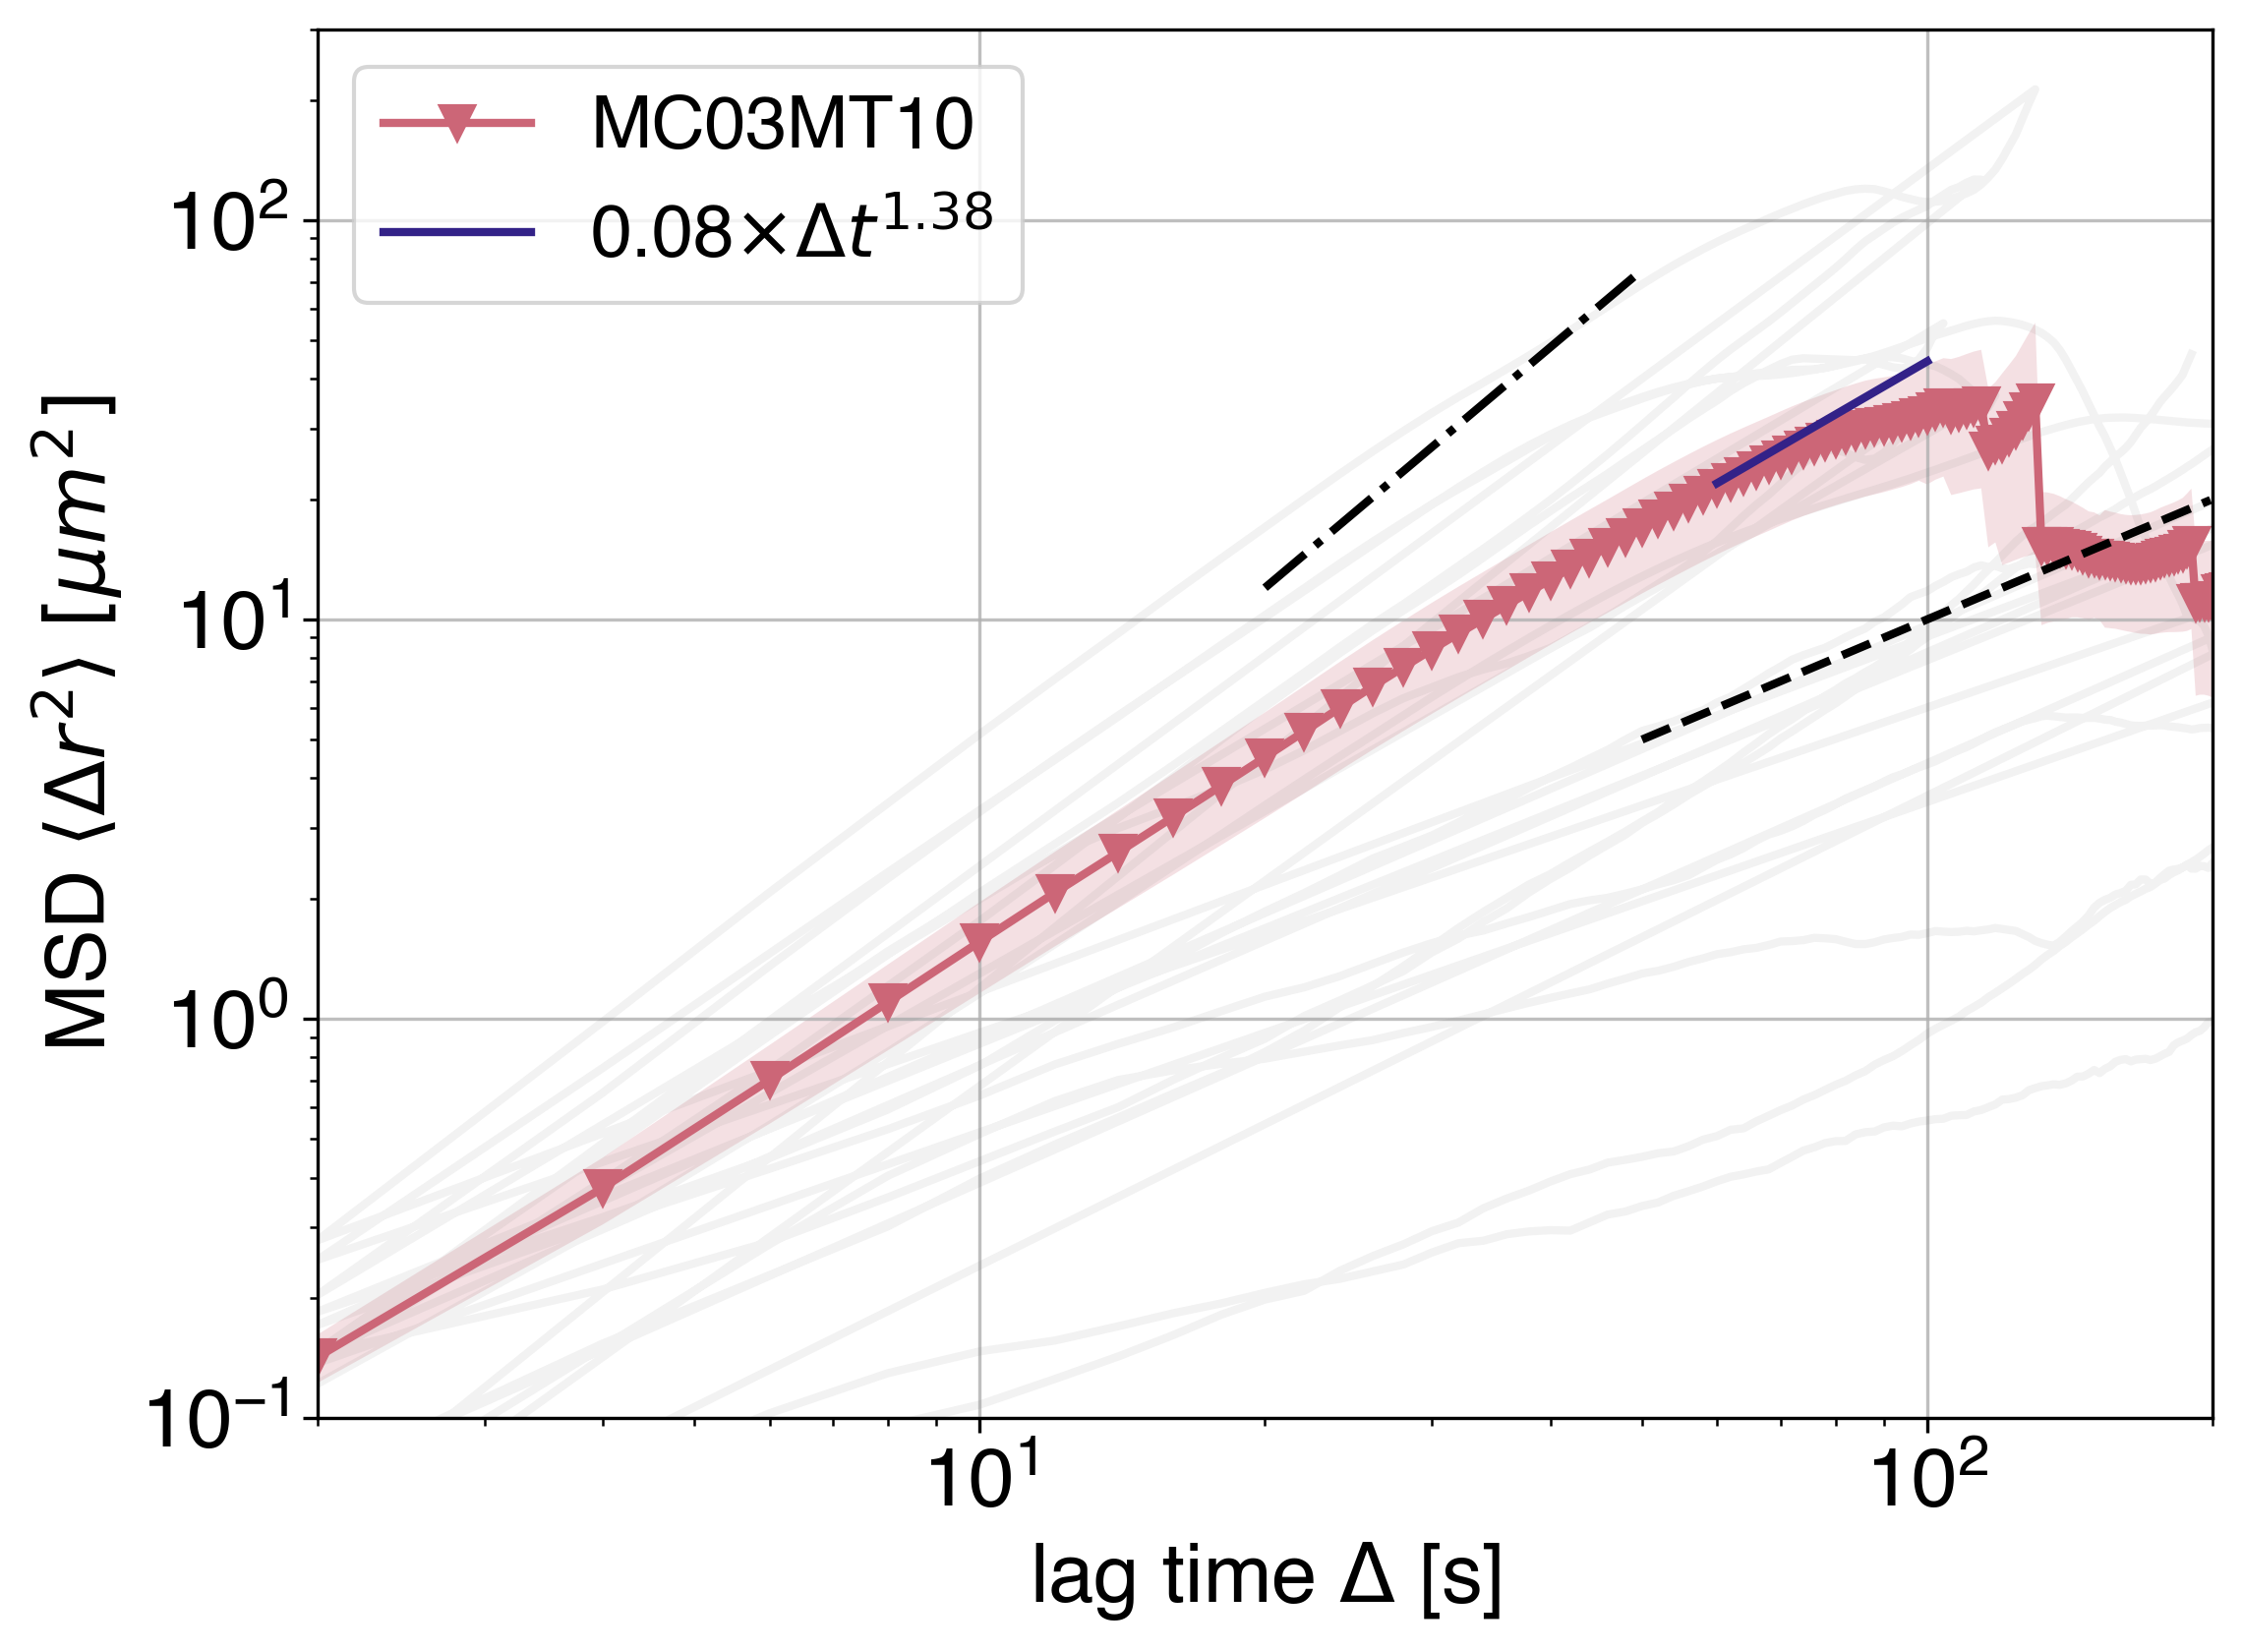

In [9]:
path3 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20260107/MC03MT10/beads_tracks.csv"

interval_h = 2
scale = 0.11

min_t = 60
max_t = 100

minimum=min_t/interval_h
maximum=max_t/interval_h

I_h3, MSD_h3 = dpm.get_msd(path3, scale, interval_h, threshold=0.0)

emsd3, emsd_err3 = dpm.get_emsd_err(I_h3)
mask = (emsd3.index > minimum) & (emsd3.index < maximum)

# take log10 of selected x and y values and convert to numpy arrays
x = np.log10(emsd3.index[mask].to_numpy())
y = np.log10(emsd3['MSD'][mask].to_numpy())
 # remove non-finite entries (e.g., log of non-positive values)
finite = np.isfinite(x) & np.isfinite(y)
x = x[finite]
y = y[finite]

# fit
popt, pcov = curve_fit(fm.ln_pl, x, y)

print(popt)

fig, ax = plt.subplots()

ax.plot(I_h3['lag time'], I_h3['MSD'], color='gray', alpha =0.1)

ax.plot(emsd3.index, emsd3['MSD'], marker=markers[2], label='MC03MT10')
ax.fill_between(emsd3.index,
                emsd3['MSD'] - emsd_err3,
                emsd3['MSD'] + emsd_err3,
                alpha=0.2)

ax.plot([min_t, max_t], fm.power_law([min_t, max_t], *popt), label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$')

t1 = np.arange(50, 200)
t2 = np.arange(20, 50)

y1 = 1.0e-1 * t1 ** 1.0
y2 = 3.0e-2 * t2 ** 2.0

ax.plot(t1, y1, c = 'black', linestyle = '--')
ax.plot(t2, y2, c = 'black', linestyle = '-.')


#ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')

ax.set(
    xlim=(2e0, 2e2),
    ylim=(1e-1, 3e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

ax.grid()
ax.legend()

<>:50: SyntaxWarning: invalid escape sequence '\D'
<>:50: SyntaxWarning: invalid escape sequence '\D'
/var/folders/bq/xf1f11f12mb4mkksc249kx6w0000gn/T/ipykernel_11240/1502481541.py:50: SyntaxWarning: invalid escape sequence '\D'
  xlabel='lag time $\Delta$ [s]',
/Users/sasakinozomu/code/MTCargo_analysis/libs/cal_vel.py:79: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  tracking_df[cols_to_assign] = tracking_df.groupby('particle').apply(
/Users/sasakinozomu/code/MTCargo_analysis/libs/displacement.py:169: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dt

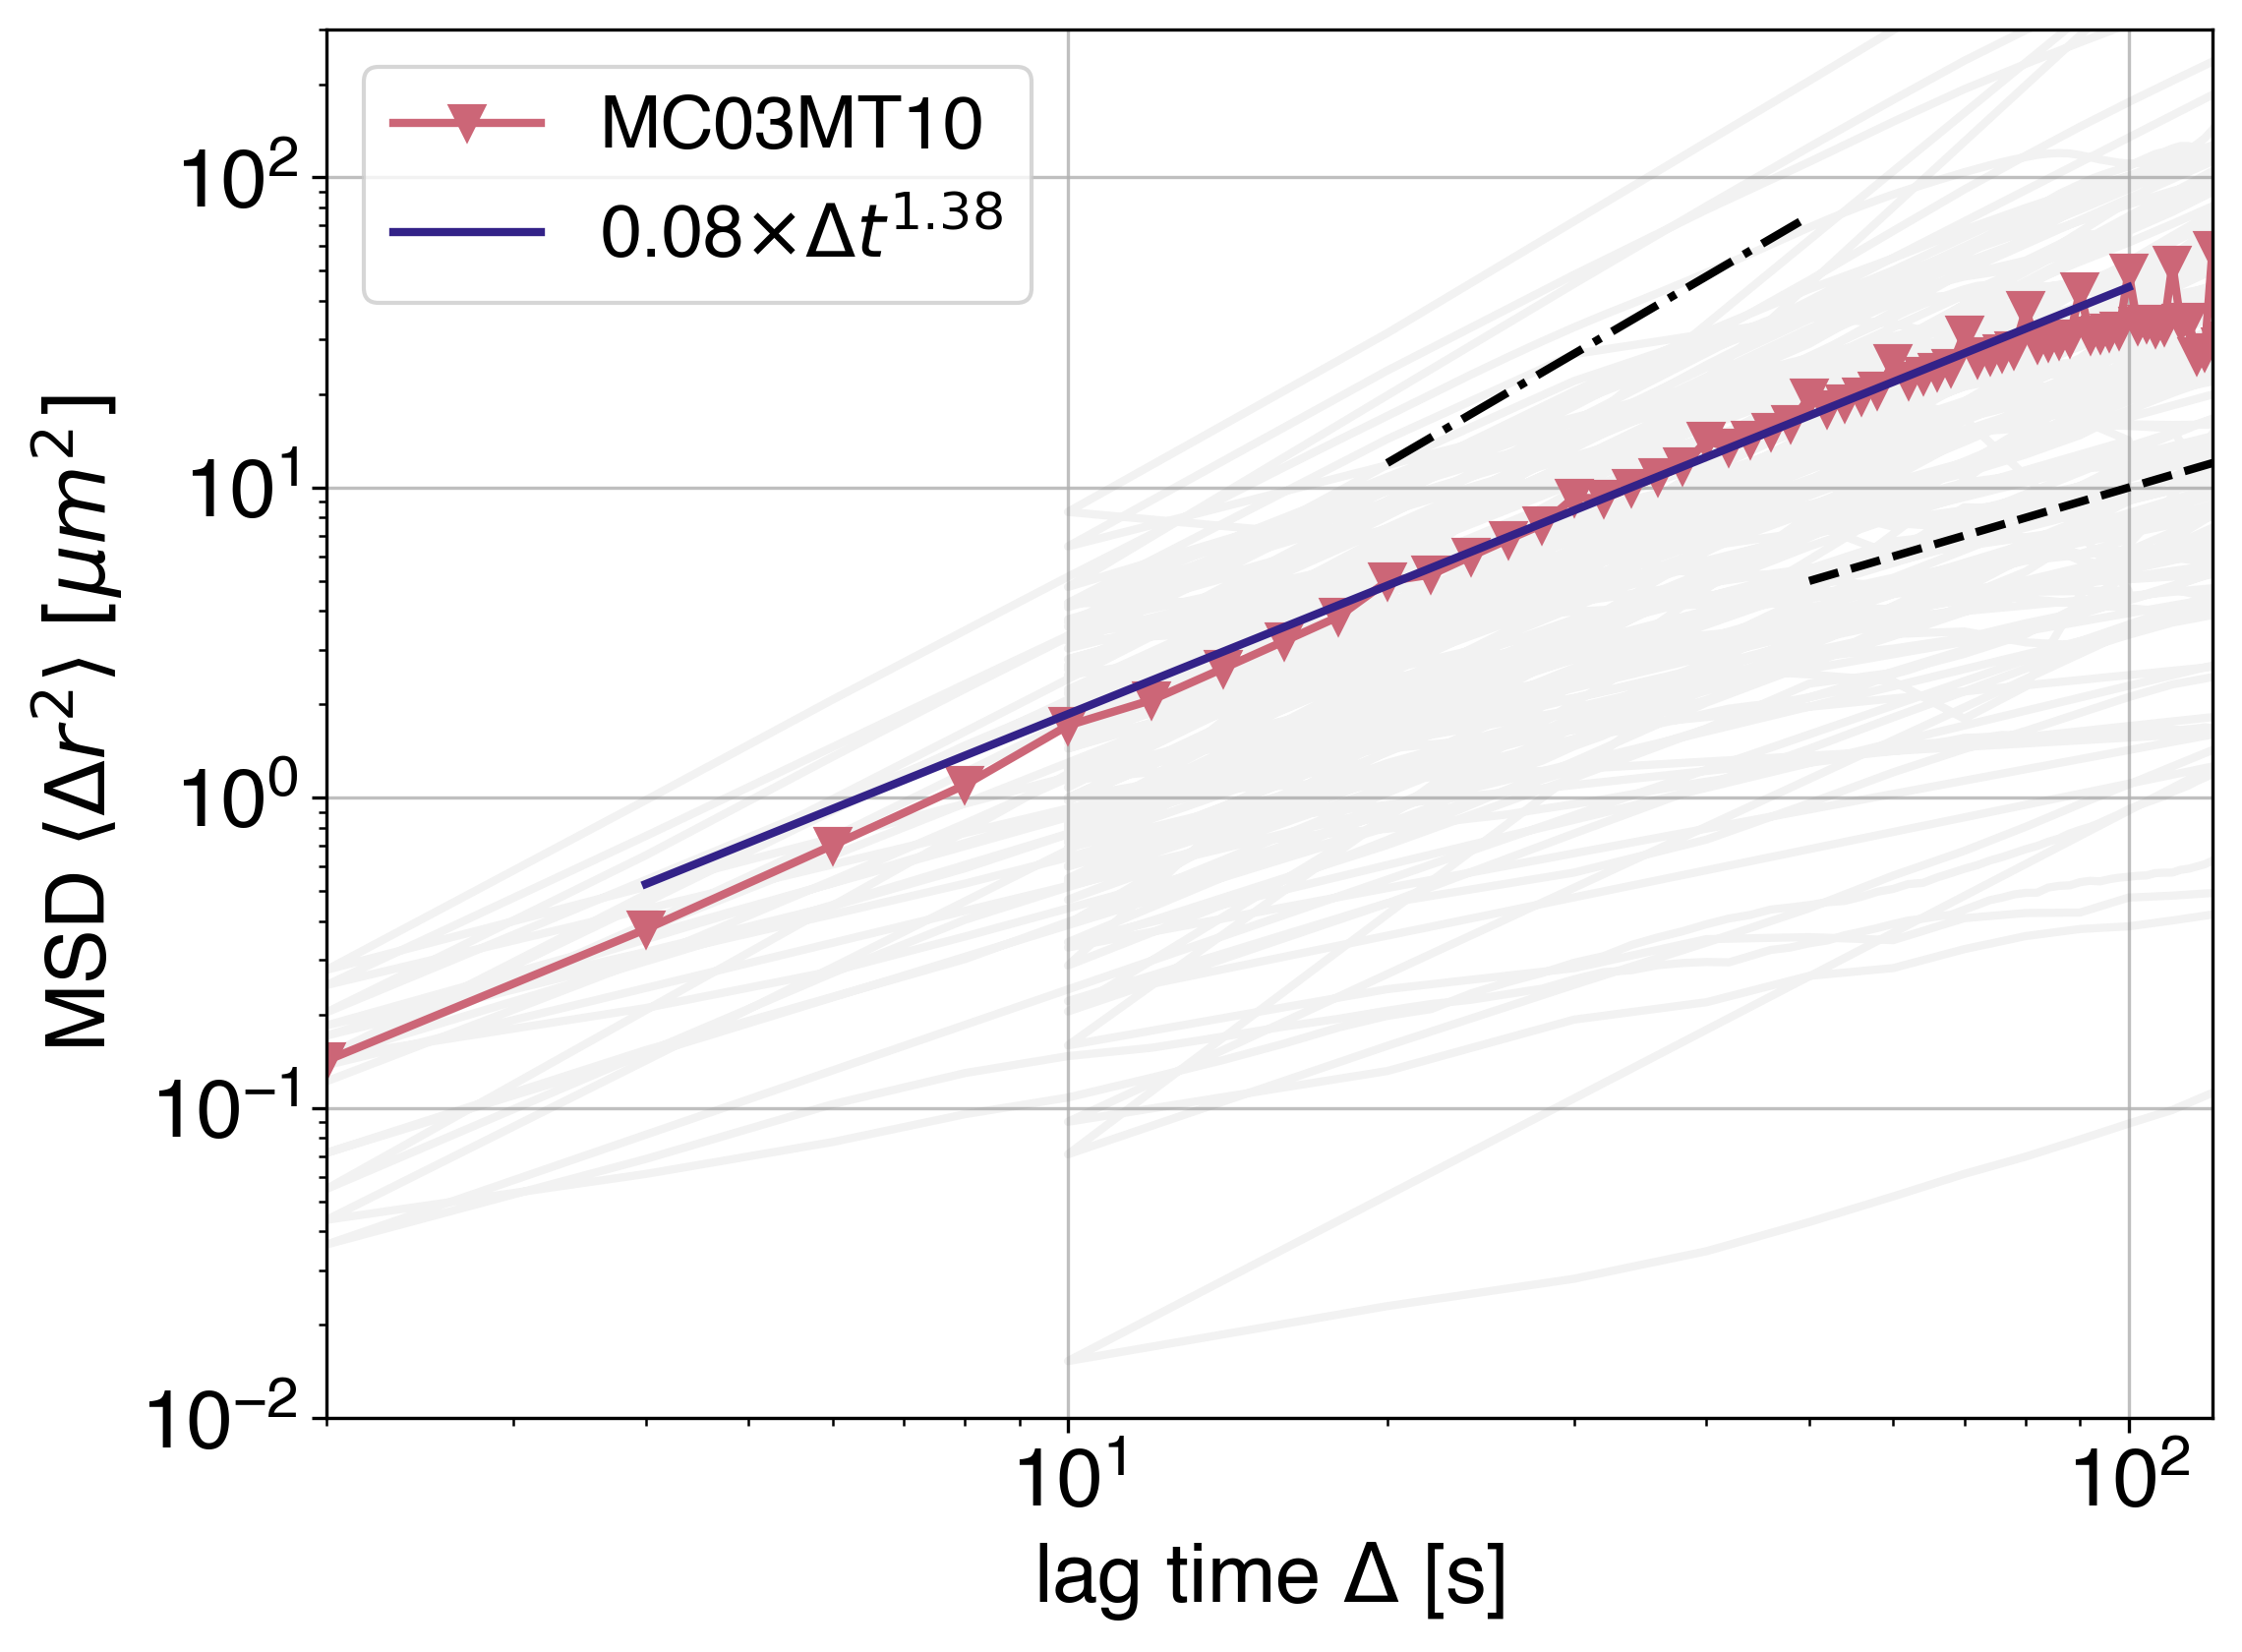

In [16]:
path3 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20260107/MC03MT10/beads_tracks.csv"
path43_2 = "/Users/sasakinozomu/code/MTCargo_analysis/experiment/20241114/MC03MT4uM/beads_tracks.csv"

interval = 10
interval_h = 2
scale = 0.11

min_t = 4
max_t = 100

minimum=min_t/interval_h
maximum=max_t/interval_h

I_h3, MSD_h3 = dpm.get_msd(path3, scale, interval_h, threshold=0.0)
I32, MSD_32 = dpm.get_msd(path43_2, scale, interval, threshold=0.0)
I32['particle'] += 10000
I_combined = pd.concat([I_h3, I32])

emsd_combined, emsd_err_combined = dpm.get_emsd_err(I_combined)

fig, ax = plt.subplots()

ax.plot(I_combined['lag time'], I_combined['MSD'], color='gray', alpha =0.1)

ax.plot(emsd_combined.index, emsd_combined['MSD'], marker=markers[2], label='MC03MT10')
"""ax.fill_between(emsd_combined.index,
                emsd_combined['MSD'] - emsd_err_combined,
                emsd_combined['MSD'] + emsd_err_combined,
                alpha=0.2)
"""
ax.plot([min_t, max_t], fm.power_law([min_t, max_t], *popt), label = f'{popt[1]:.2f}$\\times\\Delta t^{{{popt[0]:.2f}}}$')

t1 = np.arange(50, 200)
t2 = np.arange(20, 50)

y1 = 1.0e-1 * t1 ** 1.0
y2 = 3.0e-2 * t2 ** 2.0

ax.plot(t1, y1, c = 'black', linestyle = '--')
ax.plot(t2, y2, c = 'black', linestyle = '-.')


#ax.text(70, 5e1, '$\propto \Delta ^{2.0}$')

ax.set(
    xlim=(2e0, 120),
    ylim=(1e-2, 3e2),
    xscale='log',
    yscale='log',
    xlabel='lag time $\Delta$ [s]',
    ylabel='MSD $\\langle \\Delta r^2 \\rangle$ $[\u03bcm^2]$'
    )

ax.grid()
ax.legend()